<a href="https://colab.research.google.com/github/ijuzu/DL_Task1_Image_Segmentation/blob/main/Image%20Segmentation%20Model%20UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Ieva Juzumaite LSP: 2525057

In [3]:
import subprocess
subprocess.run(["pip", "install", "fiftyone", "-q"], check=True)

CompletedProcess(args=['pip', 'install', 'fiftyone', '-q'], returncode=0)

In [4]:

import os
import json
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import fcn_resnet50, \
    FCN_ResNet50_Weights
import torchvision.transforms.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, \
                            confusion_matrix, ConfusionMatrixDisplay

import fiftyone.zoo as foz

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [5]:
LABEL_MAP = {
    "background": 0,
    "Cat":        1,
    "Dog":        2,
    "Car":        3,
}
CLASS_NAMES  = ["background", "Cat", "Dog", "Car"]
NUM_CLASSES  = 4

CLASS_COLORS = np.array([
    [0,   0,   0  ],
    [255, 0,   0  ],
    [0,   255, 0  ],
    [0,   0,   255],
], dtype=np.uint8)

IMG_SIZE = (256, 256)
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

CAR_THRESHOLD = 0.55
SEEDS = [42]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

In [7]:
train_fo = foz.load_zoo_dataset(
    "open-images-v7", split="train",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=300,
)
val_fo = foz.load_zoo_dataset(
    "open-images-v7", split="validation",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=75,
)
test_fo = foz.load_zoo_dataset(
    "open-images-v7", split="test",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=100,
)

train_fo.compute_metadata()
val_fo.compute_metadata()
test_fo.compute_metadata()

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [3.8s elapsed, 0s remaining, 1.0Gb/s]         


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [3.8s elapsed, 0s remaining, 1.0Gb/s]         


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/train/metadata/classes.csv'


...

INFO:eta.core.utils: 100% |███████████████████| 75/75 [38.1ms elapsed, 0s remaining, 2.0K samples/s] 


Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████████| 100/100 [54.7ms elapsed, 0s remaining, 1.8K samples/s] 


INFO:eta.core.utils: 100% |█████████████████| 100/100 [54.7ms elapsed, 0s remaining, 1.8K samples/s] 


In [8]:
# Masking
def create_semantic_mask(sample, label_map):
    h = sample.metadata.height
    w = sample.metadata.width
    semantic_mask = np.zeros((h, w), dtype=np.uint8)
    for det in sample.ground_truth.detections:
        label = det.label
        if label not in label_map or det.mask is None:
            continue
        class_id = label_map[label]
        x_min = int(det.bounding_box[0] * w)
        y_min = int(det.bounding_box[1] * h)
        box_w = int(det.bounding_box[2] * w)
        box_h = int(det.bounding_box[3] * h)
        mask  = det.mask.astype(np.uint8)
        resized = cv2.resize(mask, (box_w, box_h),
                             interpolation=cv2.INTER_NEAREST)
        semantic_mask[y_min:y_min+box_h,
                      x_min:x_min+box_w][resized == 1] = class_id
    return semantic_mask

In [9]:
# Saving splits
def save_split(fo_dataset, split_name, label_map):
    img_dir  = f"dataset/{split_name}/images"
    mask_dir = f"dataset/{split_name}/masks"
    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)
    saved = 0
    for i, sample in enumerate(fo_dataset):
        img = cv2.imread(sample.filepath)
        if img is None:
            continue
        mask = create_semantic_mask(sample, label_map)
        cv2.imwrite(f"{img_dir}/{i:05d}.jpg", img)
        cv2.imwrite(f"{mask_dir}/{i:05d}.png", mask)
        saved += 1
    print(f"[{split_name}] saved {saved} samples.")

save_split(train_fo, "train", LABEL_MAP)
save_split(val_fo,   "val",   LABEL_MAP)
save_split(test_fo,  "test",  LABEL_MAP)

[train] saved 300 samples.
[val] saved 75 samples.
[test] saved 100 samples.


In [10]:
# Dataset
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=IMG_SIZE, augment=False):
        self.image_dir    = image_dir
        self.mask_dir     = mask_dir
        self.images       = sorted(os.listdir(image_dir))
        self.masks        = sorted(os.listdir(mask_dir))
        self.size         = size
        self.augment      = augment
        self.color_jitter = T.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2)
        self.normalise    = T.Normalize(mean=IMG_MEAN, std=IMG_STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(
            os.path.join(self.image_dir, self.images[idx])
        ).convert("RGB")
        mask = Image.open(
            os.path.join(self.mask_dir, self.masks[idx]))
        image = F.resize(image, self.size)
        mask  = F.resize(mask,  self.size, interpolation=Image.NEAREST)
        if self.augment:
            if torch.rand(1).item() > 0.5:
                image = F.hflip(image)
                mask  = F.hflip(mask)
            image = self.color_jitter(image)
        image = self.normalise(F.to_tensor(image))
        mask  = torch.tensor(np.array(mask), dtype=torch.long)
        mask  = torch.clamp(mask, 0, NUM_CLASSES - 1)
        return image, mask


def make_loaders():
    train_ds = SegmentationDataset(
        "dataset/train/images", "dataset/train/masks", augment=True)
    val_ds   = SegmentationDataset(
        "dataset/val/images",   "dataset/val/masks",   augment=False)
    test_ds  = SegmentationDataset(
        "dataset/test/images",  "dataset/test/masks",  augment=False)
    return (
        DataLoader(train_ds, batch_size=4, shuffle=True),
        DataLoader(val_ds,   batch_size=2),
        DataLoader(test_ds,  batch_size=1),
    )


#######################################################
  SEED 42  (1/1)
#######################################################
  [S42] E0 B0 loss=1.1427
  [S42] E0 B10 loss=1.1105
  [S42] E0 B20 loss=1.1059
  [S42] E0 B30 loss=1.0788
  [S42] E0 B40 loss=1.0002
  [S42] E0 B50 loss=0.9291
  [S42] E0 B60 loss=1.0073
  [S42] E0 B70 loss=0.9807
[S42] E0: tr=1.0915 vl=1.1092 lr=0.0010000
    ✓ Saved (val=1.1092)
  [S42] E1 B0 loss=1.1117
  [S42] E1 B10 loss=1.0219
  [S42] E1 B20 loss=1.1112
  [S42] E1 B30 loss=1.1524
  [S42] E1 B40 loss=0.9937
  [S42] E1 B50 loss=1.0529
  [S42] E1 B60 loss=1.0928
  [S42] E1 B70 loss=1.0055
[S42] E1: tr=1.0241 vl=1.0694 lr=0.0010000
    ✓ Saved (val=1.0694)
  [S42] E2 B0 loss=0.9660
  [S42] E2 B10 loss=0.9811
  [S42] E2 B20 loss=1.1526
  [S42] E2 B30 loss=0.8356
  [S42] E2 B40 loss=1.0777
  [S42] E2 B50 loss=1.0721
  [S42] E2 B60 loss=0.9665
  [S42] E2 B70 loss=1.1110
[S42] E2: tr=0.9871 vl=1.0951 lr=0.0010000
    No improvement 1/10
  [S42] E3 B0 loss=0.9

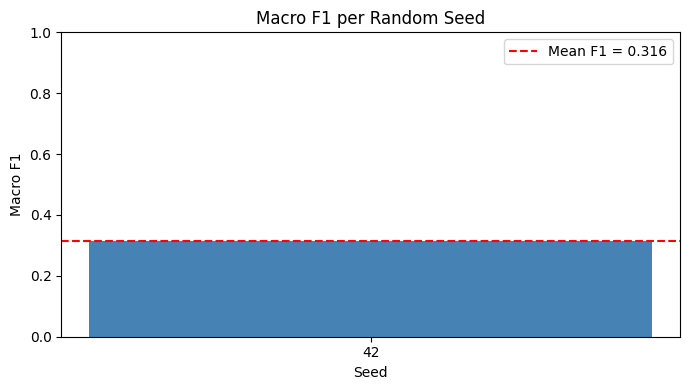


Using seed 42 for analysis.


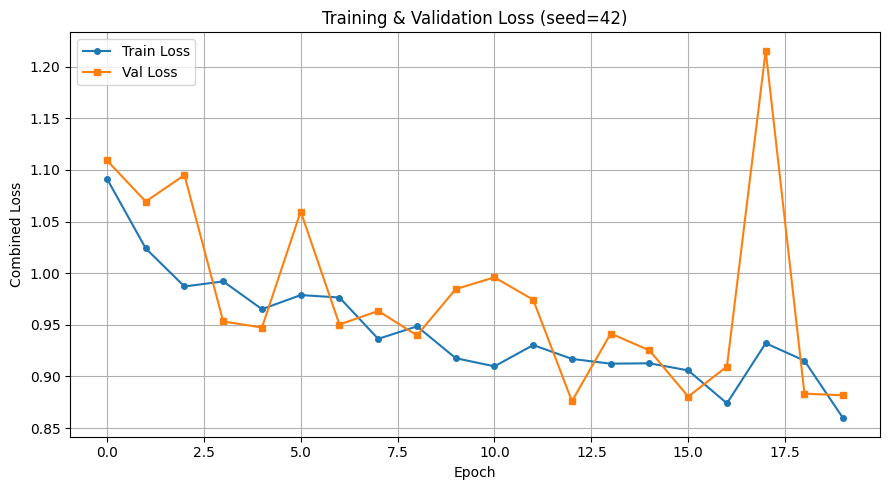

In [ ]:
# Model

class SEBlock(nn.Module):
    """
    Squeeze-and-excitation block, scales each feature channel by its importance
    """
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(x)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.se      = SEBlock(out_ch)
        self.dropout = (nn.Dropout2d(p=dropout)
                        if dropout > 0 else nn.Identity())

    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        x = self.dropout(x)
        return x


class AttentionGate(nn.Module):
    """
    Attention gate
    skip_ch:  channels of the encoder skip feature
    gate_ch:  channels of the decoder signal
    inter_ch: intermediate channels
    """
    def __init__(self, skip_ch, gate_ch, inter_ch):
        super().__init__()
        self.Wg  = nn.Conv2d(gate_ch,  inter_ch, 1)
        self.Wx  = nn.Conv2d(skip_ch,  inter_ch, 1)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_ch, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, g):
        psi = self.psi(self.Wg(g) + self.Wx(x))
        return x * psi


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up  = nn.ConvTranspose2d(in_ch, in_ch//2,
                                      kernel_size=2, stride=2)
        self.att = AttentionGate(skip_ch=skip_ch,
                                 gate_ch=in_ch//2,
                                 inter_ch=max(skip_ch//2, 1))
        self.conv = ConvBlock(in_ch//2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = torch_F.interpolate(x, size=skip.shape[2:],
                                    mode='bilinear', align_corners=False)
        skip = self.att(skip, x)   # gate before concatenation
        return self.conv(torch.cat([x, skip], dim=1))


class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1       = ConvBlock(3,   64)
        self.enc2       = ConvBlock(64,  128)
        self.enc3       = ConvBlock(128, 256)
        self.pool       = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(256, 256, dropout=0.4)
        self.up1        = UpBlock(256, 256, 128)
        self.up2        = UpBlock(128, 128,  64)
        self.up3        = UpBlock( 64,  64,  32)
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        b  = self.bottleneck(self.pool(s3))
        x  = self.up1(b,  s3)
        x  = self.up2(x,  s2)
        x  = self.up3(x,  s1)
        return self.final_conv(x)  # [B, 4, 256, 256]


def build_model():
    return UNet(num_classes=NUM_CLASSES).to(device)


# Loss functin

class ForegroundDiceLoss(nn.Module):
    """
    Dice on only foreground classes (Cat=1, Dog=2, Car=3).
    """
    def __init__(self, num_classes=NUM_CLASSES, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth      = smooth

    def forward(self, logits, targets):
        probs   = torch_F.softmax(logits, dim=1)
        one_hot = torch_F.one_hot(
            targets, self.num_classes).permute(0,3,1,2).float()
        probs_fg   = probs[:, 1:, :, :]
        one_hot_fg = one_hot[:, 1:, :, :]
        dims  = (0, 2, 3)
        inter = (probs_fg * one_hot_fg).sum(dim=dims)
        union = probs_fg.sum(dim=dims) + one_hot_fg.sum(dim=dims)
        return 1 - ((2*inter+self.smooth)/(union+self.smooth)).mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.ce   = nn.CrossEntropyLoss(
            weight=torch.tensor([0.1, 5.0, 5.0, 1.5]).to(device))
        self.dice = ForegroundDiceLoss()

    def forward(self, logits, targets):
        return (self.alpha * self.ce(logits, targets) +
                (1-self.alpha) * self.dice(logits, targets))


# Confidence threshold for Car
def predict_with_threshold(logits, car_idx=3, threshold=CAR_THRESHOLD):
    """Post-processing calibration. Only labels Car at >= 0.55 confidence."""
    probs    = torch_F.softmax(logits, dim=1)
    pred     = torch.argmax(probs, dim=1)
    low_conf = (pred == car_idx) & (probs[:, car_idx] < threshold)
    if low_conf.any():
        no_car             = probs.clone()
        no_car[:, car_idx] = 0.0
        pred[low_conf]     = torch.argmax(no_car, dim=1)[low_conf]
    return pred


# Early stopping
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001,
                 save_path="best_model.pth"):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter   = 0

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"    ✓ Saved (val={val_loss:.4f})")
            return False
        self.counter += 1
        print(f"    No improvement {self.counter}/{self.patience}")
        return self.counter >= self.patience


# Training loop
def run_training(model, criterion, train_loader, val_loader,
                 optimizer, scheduler, early_stop,
                 max_epochs, label, stats):
    for epoch in range(max_epochs):
        model.train()
        tr_sum = 0.0
        for bi, (imgs, masks) in enumerate(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            loss = criterion(model(imgs), masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr_sum += loss.item()
            if bi % 10 == 0:
                print(f"  [{label}] E{epoch} B{bi} "
                      f"loss={loss.item():.4f}")
        tr_loss = tr_sum / len(train_loader)

        model.eval()
        vl_sum = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                vl_sum += criterion(model(imgs), masks).item()
        vl_loss = vl_sum / len(val_loader)

        lr = optimizer.param_groups[0]['lr']
        print(f"[{label}] E{epoch}: "
              f"tr={tr_loss:.4f} vl={vl_loss:.4f} lr={lr:.7f}")

        stats.append({"epoch": epoch,
                      "train_loss": round(tr_loss, 5),
                      "val_loss":   round(vl_loss, 5),
                      "lr":         round(lr, 7)})
        with open("training_stats.json", "w") as f:
            json.dump(stats, f, indent=2)

        scheduler.step(vl_loss)
        if early_stop.step(vl_loss, model):
            print(f"[{label}] Early stop at epoch {epoch}. "
                  f"Best={early_stop.best_loss:.4f}")
            return


# Evaluation
def evaluate(model, loader, device, split_name="Test",
             use_threshold=True, dict_output=False):
    """
    Metrics across ALL pixels of ALL images in loader.
    All numbers are real overall metrics, not filtered to hard cases.
    Macro F1 = mean of the 4 per-class F1 values.
    """
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            if dict_output:
                out = out['out']
            p = (predict_with_threshold(out) if use_threshold
                 else torch.argmax(out, dim=1))
            preds_all.extend(p.cpu().numpy().flatten())
            labels_all.extend(masks.numpy().flatten())

    P, L = np.array(preds_all), np.array(labels_all)
    acc      = (P == L).sum() / len(L)
    prec_mac = precision_score(L, P, average='macro', zero_division=0)
    rec_mac  = recall_score(   L, P, average='macro', zero_division=0)
    f1_mac   = f1_score(       L, P, average='macro', zero_division=0)
    prec_per = precision_score(L, P, average=None,    zero_division=0)
    rec_per  = recall_score(   L, P, average=None,    zero_division=0)
    f1_per   = f1_score(       L, P, average=None,    zero_division=0)

    tag = "with Car threshold" if use_threshold else "baseline argmax"
    print(f"\n{'='*58}")
    print(f"  {split_name} — {tag}")
    print(f"  Computed across ALL {len(loader)} images")
    print(f"{'='*58}")
    print(f"  Pixel Accuracy : {acc:.4f}")
    print(f"  Macro Precision: {prec_mac:.4f}")
    print(f"  Macro Recall   : {rec_mac:.4f}")
    print(f"  Macro F1       : {f1_mac:.4f}  ← main metric")
    print(f"\n  Per-class (real F1 per class):")
    print(f"  {'Class':<12} {'P':>7} {'R':>7} {'F1':>7}")
    for i, name in enumerate(CLASS_NAMES):
        if i < len(prec_per):
            note = " ← best" if f1_per[i]==max(f1_per) else (
                   " ← hardest" if f1_per[i]==min(f1_per) else "")
            print(f"  {name:<12} {prec_per[i]:>7.3f} "
                  f"{rec_per[i]:>7.3f} {f1_per[i]:>7.3f}{note}")
    print(f"\n  Macro F1 = mean("
          f"{', '.join(f'{v:.3f}' for v in f1_per)}) = {f1_mac:.4f}")
    print(f"{'='*58}\n")

    return {"accuracy": float(acc), "precision": float(prec_mac),
            "recall":   float(rec_mac), "f1": float(f1_mac),
            "f1_per_class": {CLASS_NAMES[i]: float(f1_per[i])
                             for i in range(len(f1_per))}}


# Multi-seed training
all_seed_metrics = []

for seed in SEEDS:
    print(f"\n{'#'*55}")
    print(f"  SEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})")
    print(f"{'#'*55}")

    set_seed(seed)
    model      = build_model()
    criterion  = CombinedLoss(alpha=0.5)
    train_loader, val_loader, test_loader = make_loaders()
    stats      = []

    optimizer  = torch.optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4)
    early_stop = EarlyStopping(
        patience=10, save_path=f"best_unet_seed{seed}.pth")

    run_training(model, criterion, train_loader, val_loader,
                 optimizer, scheduler, early_stop,
                 max_epochs=20, label=f"S{seed}", stats=stats)

    model.load_state_dict(torch.load(f"best_unet_seed{seed}.pth"))
    model.eval()

    with open(f"training_stats_seed{seed}.json", "w") as f:
        json.dump(stats, f, indent=2)

    print(f"\n─── Seed {seed}: baseline ───")
    evaluate(model, test_loader, device,
             split_name=f"Test seed={seed}", use_threshold=False)
    print(f"─── Seed {seed}: with Car threshold ───")
    m = evaluate(model, test_loader, device,
                 split_name=f"Test seed={seed}", use_threshold=True)
    m["seed"] = seed
    all_seed_metrics.append(m)


# Showing seed summary (when there are multiple seeds)
print(f"\n{'='*58}")
print(f"  Multi-Seed Summary ({len(SEEDS)} seeds: {SEEDS})")
print(f"{'='*58}")
for metric in ["accuracy", "precision", "recall", "f1"]:
    vals = [m[metric] for m in all_seed_metrics]
    print(f"  {metric.capitalize():<12} "
          f"{np.mean(vals):.4f} ± {np.std(vals):.4f}")
print(f"\n  Per-class F1:")
for cls in CLASS_NAMES:
    vals = [m["f1_per_class"].get(cls, 0) for m in all_seed_metrics]
    print(f"    {cls:<12} {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print("="*58)

with open("multiseed_summary.json", "w") as f:
    json.dump({
        "seeds": SEEDS, "runs": all_seed_metrics,
        "mean_f1": float(np.mean([m["f1"] for m in all_seed_metrics])),
        "std_f1":  float(np.std( [m["f1"] for m in all_seed_metrics])),
    }, f, indent=2)

plt.figure(figsize=(7, 4))
f1s = [m["f1"] for m in all_seed_metrics]
plt.bar([str(m["seed"]) for m in all_seed_metrics],
        f1s, color='steelblue', width=0.4)
plt.axhline(np.mean(f1s), color='red', linestyle='--',
            label=f"Mean F1 = {np.mean(f1s):.3f}")
plt.ylim(0.0, 1.0)
plt.xlabel("Seed")
plt.ylabel("Macro F1")
plt.title("Macro F1 per Random Seed")
plt.legend()
plt.tight_layout()
plt.savefig("multiseed_f1.png")
plt.show()


# Best seed
best_seed = max(all_seed_metrics, key=lambda m: m["f1"])["seed"]
print(f"\nUsing seed {best_seed} for analysis.")
set_seed(best_seed)
model = build_model()
model.load_state_dict(torch.load(f"best_unet_seed{best_seed}.pth"))
model.eval()
_, _, test_loader = make_loaders()
criterion = CombinedLoss(alpha=0.5)
best_metrics = all_seed_metrics[
    [m["seed"] for m in all_seed_metrics].index(best_seed)]


# Training curves
with open(f"training_stats_seed{best_seed}.json") as f:
    best_stats = json.load(f)

plt.figure(figsize=(9, 5))
plt.plot([s["epoch"] for s in best_stats],
         [s["train_loss"] for s in best_stats],
         label="Train Loss", marker='o', markersize=4)
plt.plot([s["epoch"] for s in best_stats],
         [s["val_loss"] for s in best_stats],
         label="Val Loss", marker='s', markersize=4)
plt.title(f"Training & Validation Loss (seed={best_seed})")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()


# Comparison with pretrained ResNet50 model
# PASCAL class mapping: cat(8)→Cat(1), dog(12)→Dog(2), car(7)→Car(3)

PASCAL_CAT, PASCAL_DOG, PASCAL_CAR = 8, 12, 7

bench_model = fcn_resnet50(
    weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
).to(device)
bench_model.eval()

preds_bench, labels_bench = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        out  = bench_model(imgs)['out']
        p    = torch.argmax(out, dim=1)
        our  = torch.zeros_like(p)
        our[p == PASCAL_CAT] = 1
        our[p == PASCAL_DOG] = 2
        our[p == PASCAL_CAR] = 3
        preds_bench.extend(our.cpu().numpy().flatten())
        labels_bench.extend(masks.numpy().flatten())

P_b, L_b = np.array(preds_bench), np.array(labels_bench)
bench_metrics = {
    "accuracy":  float((P_b==L_b).sum()/len(L_b)),
    "precision": float(precision_score(L_b,P_b,average='macro',
                                       zero_division=0)),
    "recall":    float(recall_score(   L_b,P_b,average='macro',
                                       zero_division=0)),
    "f1":        float(f1_score(       L_b,P_b,average='macro',
                                       zero_division=0)),
}
bench_f1_per = f1_score(L_b, P_b, average=None, zero_division=0)

print(f"\n{'='*62}")
print(f"  Benchmark: FCN-ResNet50 pretrained (zero-shot)")
print(f"  {'Metric':<16} {'Custom U-Net':>14} {'FCN-ResNet50':>14}  Winner")
print(f"  {'-'*58}")
for key in ["accuracy","precision","recall","f1"]:
    our = best_metrics[key]
    ben = bench_metrics[key]
    win = "← ours" if our >= ben else "← pretrained"
    print(f"  {key.capitalize():<16} {our:>14.4f} {ben:>14.4f}  {win}")
print(f"\n  Per-class F1:")
for i, cls in enumerate(CLASS_NAMES):
    our = best_metrics["f1_per_class"].get(cls, 0)
    ben = float(bench_f1_per[i]) if i < len(bench_f1_per) else 0
    print(f"    {cls:<12} ours={our:.3f}  pretrained={ben:.3f}")
print("="*62)

with open("benchmark_comparison.json", "w") as f:
    json.dump({"custom_unet":         best_metrics,
               "fcn_resnet50_zeroshot": bench_metrics}, f, indent=2)


# Confusion matrix
def plot_confusion_matrix(model, loader, device, use_threshold=True):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            p    = (predict_with_threshold(out) if use_threshold
                    else torch.argmax(out, dim=1))
            preds_all.extend(p.cpu().numpy().flatten())
            labels_all.extend(masks.numpy().flatten())

    cm = confusion_matrix(labels_all, preds_all,
                          labels=list(range(NUM_CLASSES)),
                          normalize='true')
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title("Normalised Confusion Matrix\n"
                 "(row = true class, col = predicted class)")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()
    print("\nKey findings:")
    print(f"  BG→Car  : {cm[0,3]*100:.1f}%  (false Car positives)")
    print(f"  Car→Car : {cm[3,3]*100:.1f}%  (Car recall)")
    print(f"  Cat→Cat : {cm[1,1]*100:.1f}%  (Cat accuracy)")
    print(f"  Dog→Cat : {cm[2,1]*100:.1f}%  (Dog/Cat confusion)")

plot_confusion_matrix(model, test_loader, device, use_threshold=True)


# Residual/error analysis
def denorm(tensor):
    """Reverse normalisation for display. Clamps output to [0,1]."""
    mean = torch.tensor(IMG_MEAN).view(3,1,1)
    std  = torch.tensor(IMG_STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0.0, 1.0)


def residual_analysis(model, loader, device, n_worst=5,
                      use_threshold=True):
    model.eval()
    records  = []
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out  = model(imgs)
            loss = criterion(out, masks)
            p    = (predict_with_threshold(out) if use_threshold
                    else torch.argmax(out, dim=1))
            pn = p.cpu().numpy().flatten()
            mn = masks.cpu().numpy().flatten()
            for c in range(NUM_CLASSES):
                tp[c] += ((pn==c)&(mn==c)).sum()
                fp[c] += ((pn==c)&(mn!=c)).sum()
                fn[c] += ((pn!=c)&(mn==c)).sum()
            records.append((loss.item(),
                            imgs.cpu(), masks.cpu(), out.cpu()))

    records.sort(key=lambda r: r[0], reverse=True)

    print("\n"+"="*62)
    print(" Residual Analysis — Per-Class Error Rates (all 100 images)")
    print("="*62)
    print(f"  {'Class':<12} {'FP rate':>9} {'FN rate':>9} "
          f"{'TP pixels':>12}")
    for c, name in enumerate(CLASS_NAMES):
        fpr = fp[c]/(tp[c]+fp[c]) if (tp[c]+fp[c])>0 else 0
        fnr = fn[c]/(tp[c]+fn[c]) if (tp[c]+fn[c])>0 else 0
        print(f"  {name:<12} {fpr:>9.3f} {fnr:>9.3f} "
              f"{int(tp[c]):>12,}")
    print()
    print("  FP rate = fraction of predicted-as-X pixels that are wrong")
    print("  FN rate = fraction of true-X pixels the model missed")
    print("="*62)

    modes = [
        "Car/BG boundary confusion — encoder limitation",
        "Small/distant object lost in downsampling",
        "Annotation boundary noise",
        "Multiple overlapping instances",
        "Unusual viewpoint or lighting",
    ]

    fig, axes = plt.subplots(n_worst, 3, figsize=(13, n_worst*4))
    print(f"\nTop {n_worst} images with highest loss:")
    for row, (lv, img, mask, out) in enumerate(records[:n_worst]):
        p = (predict_with_threshold(out) if use_threshold
             else torch.argmax(out, dim=1))
        img_display = denorm(img.squeeze()).permute(1,2,0).numpy()
        axes[row,0].imshow(img_display)
        axes[row,0].set_title(f"Image (loss={lv:.3f})")
        axes[row,0].axis('off')
        axes[row,1].imshow(CLASS_COLORS[mask.squeeze().numpy()])
        axes[row,1].set_title("Ground Truth")
        axes[row,1].axis('off')
        axes[row,2].imshow(CLASS_COLORS[p.squeeze().numpy()])
        axes[row,2].set_title("Prediction")
        axes[row,2].axis('off')
        print(f"  Rank {row+1}: loss={lv:.4f} — "
              f"{modes[row] if row<len(modes) else ''}")

    plt.suptitle("Residual Analysis — 5 Worst Predictions\n"
                 "Black=BG  Red=Cat  Green=Dog  Blue=Car", fontsize=13)
    plt.tight_layout()
    plt.savefig("residual_analysis.png")
    plt.show()

residual_analysis(model, test_loader, device,
                  n_worst=5, use_threshold=True)

In [3]:
# Prediction
def predict_image(model, image_path, device, size=IMG_SIZE,
                  use_threshold=True):
    model.eval()
    norm = T.Normalize(mean=IMG_MEAN, std=IMG_STD)
    orig = Image.open(image_path).convert("RGB")
    t    = norm(F.to_tensor(F.resize(orig, size))).unsqueeze(0).to(device)
    with torch.no_grad():
        out  = model(t)
        pred = (predict_with_threshold(out) if use_threshold
        else torch.argmax(out, dim=1))
        pred = pred.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(np.array(orig))
    axes[0].set_title("Input Image")
    axes[0].axis('off')
    axes[1].imshow(CLASS_COLORS[pred])
    axes[1].set_title(
        "Segmentation\nBlack=BG  Red=Cat  Green=Dog  Blue=Car")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig("single_image_prediction.png")
    plt.show()
    return pred

# predict_image(model, "test_image.jpg", device


NameError: name 'IMG_SIZE' is not defined